<a href="https://colab.research.google.com/github/YashitaaArya/Python-Practices/blob/main/HMDNumericalImputation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **HANDLING MISSING DATA**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [4]:
df=pd.read_csv("titanic_toy.csv")

In [5]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [6]:
df.shape

(891, 4)

In [7]:
df.isnull().mean()

,0
Age,0.198653
Fare,0.050505
Family,0.000000
Survived,0.000000


In [8]:
x=df.drop(columns=["Survived"])
y=df["Survived"]

In [9]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [10]:
x_train.shape,x_test.shape

((712, 3), (179, 3))

In [11]:
x_train.isnull().mean()

,0
Age,0.196629
Fare,0.050562
Family,0.000000


In [12]:
mean_age=x_train['Age'].mean()
median_age=x_train['Age'].median()

mean_fare=x_train['Fare'].mean()
median_fare=x_train['Fare'].median()

In [13]:
x_train['Age_mean']=x_train['Age'].fillna(mean_age)
x_train['Age_median']=x_train['Age'].fillna(median_age)

x_train['Fare_mean']=x_train['Fare'].fillna(mean_fare)
x_train['Fare_median']=x_train['Fare'].fillna(median_fare)

In [14]:
print("Original Age variable variance: ", x_train['Age'].var())
print("Age Variance after median imputation: ", x_train['Age_median'].var())
print("Age Variance after mean imputation: ", x_train['Age_mean'].var())

print("Original Fare variable variance: ", x_train['Fare'].var())
print("Fare Variance after median imputation: ", x_train['Fare_median'].var())
print("Fare Variance after mean imputation: ", x_train['Fare_mean'].var())

Original Age variable variance:  210.2517072477438
Age Variance after median imputation:  169.20731007048096
Age Variance after mean imputation:  168.8519336687225
Original Fare variable variance:  2761.031434948639
Fare Variance after median imputation:  2637.01248167777
Fare Variance after mean imputation:  2621.2323749512393


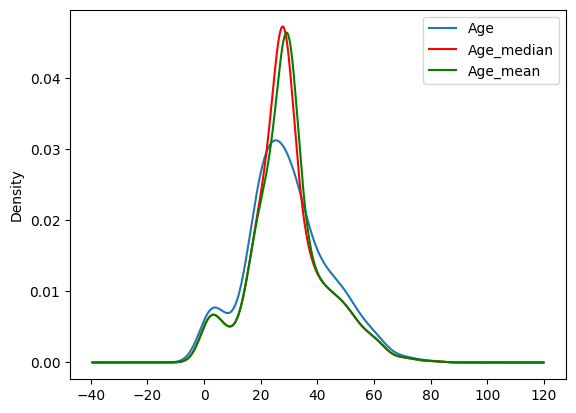

In [15]:
fig=plt.figure()
ax=fig.add_subplot(111)

# original variable distribution
x_train['Age'].plot(kind='kde',ax=ax)

# variable imputed with the median
x_train['Age_median'].plot(kind='kde',ax=ax,color='red')

# variable imputed with the mean
x_train['Age_mean'].plot(kind='kde',ax=ax,color='green')

# add legends
lines, labels=ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')

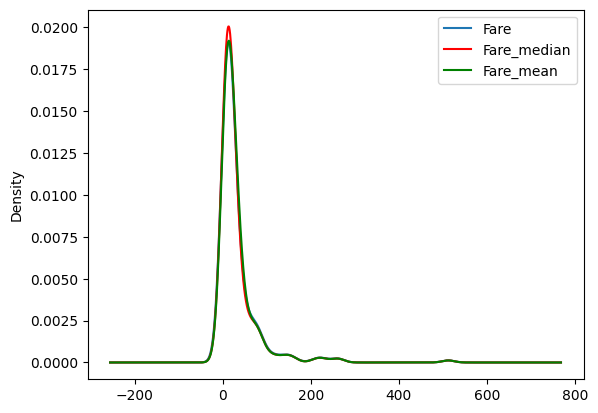

In [17]:
fig=plt.figure()
ax=fig.add_subplot(111)
x_train['Fare'].plot(kind='kde',ax=ax)
x_train['Fare_median'].plot(kind='kde',ax=ax,color='red')
x_train['Fare_mean'].plot(kind='kde',ax=ax,color='green')
lines, labels=ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')

In [18]:
x_train.cov()

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
Age,210.251707,75.481375,-6.993325,210.251707,210.251707,71.193767,70.082085
Fare,75.481375,2761.031435,18.599163,60.224654,63.938058,2761.031435,2761.031435
Family,-6.993325,18.599163,2.830892,-5.616299,-5.587710,17.657433,17.672035
Age_mean,210.251707,60.224654,-5.616299,168.851934,168.851934,57.175304,56.282518
Age_median,210.251707,63.938058,-5.587710,168.851934,169.207310,60.700688,59.728510
Fare_mean,71.193767,2761.031435,17.657433,57.175304,60.700688,2621.232375,2621.232375
Fare_median,70.082085,2761.031435,17.672035,56.282518,59.728510,2621.232375,2637.012482


In [19]:
x_train.corr()

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
Age,1.000000,0.091482,-0.319651,1.000000,1.000000,0.088944,0.087232
Fare,0.091482,1.000000,0.207193,0.088151,0.093496,1.000000,1.000000
Family,-0.319651,0.207193,1.000000,-0.256883,-0.255307,0.204981,0.204536
Age_mean,1.000000,0.088151,-0.256883,1.000000,0.998949,0.085941,0.084346
Age_median,1.000000,0.093496,-0.255307,0.998949,1.000000,0.091145,0.089416
Fare_mean,0.088944,1.000000,0.204981,0.085941,0.091145,1.000000,0.997003
Fare_median,0.087232,1.000000,0.204536,0.084346,0.089416,0.997003,1.000000


<Axes: >

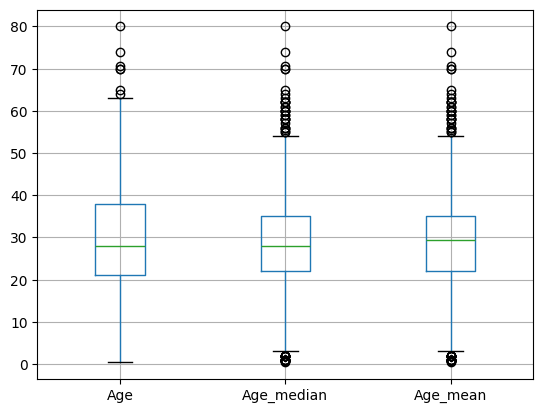

In [20]:
x_train[['Age', 'Age_median', 'Age_mean']].boxplot()

<Axes: >

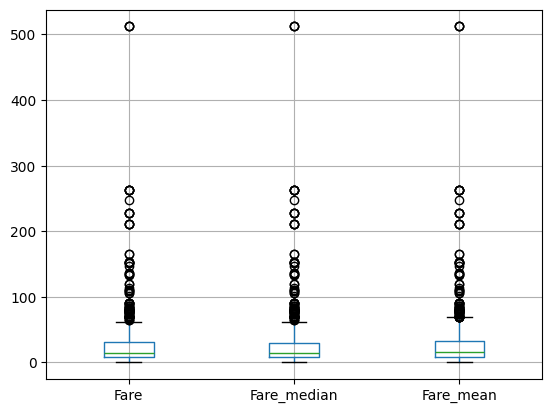

In [21]:
x_train[['Fare', 'Fare_median', 'Fare_mean']].boxplot()

In [22]:
# using sklearn
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [23]:
imputer1=SimpleImputer(strategy='median')
imputer2=SimpleImputer(strategy='mean')

In [24]:
trf=ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
],remainder='passthrough')

In [25]:
trf.fit(x_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1', SimpleImputer(strategy='median'),
                                 ['Age']),
                                ('imputer2', SimpleImputer(), ['Fare'])])

In [27]:
trf.named_transformers_['imputer1'].statistics_

array([28.75])

In [28]:
trf.named_transformers_['imputer2'].statistics_

array([32.61759689])

In [29]:
x_train=trf.transform(x_train)
x_test=trf.transform(x_test)

In [30]:
x_train

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 28.75  , 221.7792,   0.    ],
       [ 28.75  ,  25.925 ,   0.    ]])

ARBITRARY VALUE IMPUTATION

In [31]:
newdf=pd.read_csv("titanic_toy.csv")

In [32]:
newdf.isnull().mean()

,0
Age,0.198653
Fare,0.050505
Family,0.000000
Survived,0.000000


In [34]:
X=newdf.drop(columns=["Survived"])
Y=newdf["Survived"]

In [35]:
X_train, X_test, Y_train, Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [36]:
X_train['Age_99']=X_train['Age'].fillna(99)
X_train['Age_minus1']=X_train['Age'].fillna(-1)

X_train['Fare_999']=X_train['Fare'].fillna(999)
X_train['Fare_minus1']=X_train['Fare'].fillna(-1)

In [37]:
print("Original Age variable variance: ", X_train['Age'].var())
print("Age Variance after 99 imputation: ", X_train['Age_99'].var())
print("Age Variance after -1 imputation: ", X_train['Age_minus1'].var())

print("Original Fare variable variance: ", X_train['Fare'].var())
print("Fare Variance after 999 imputation: ", X_train['Fare_999'].var())
print("Fare Variance after -1 imputation: ", X_train['Fare_minus1'].var())

Original Age variable variance:  210.2517072477438
Age Variance after 99 imputation:  932.9665366701436
Age Variance after -1 imputation:  315.99550362600644
Original Fare variable variance:  2761.031434948639
Fare Variance after 999 imputation:  47525.47059536007
Fare Variance after -1 imputation:  2675.2394049177087


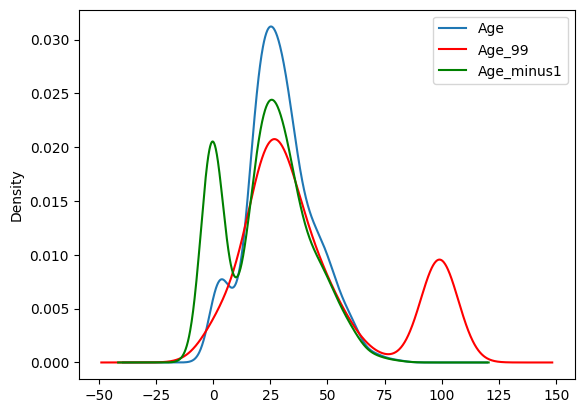

In [38]:
fig=plt.figure()
ax=fig.add_subplot(111)

# original variable distribution
X_train['Age'].plot(kind='kde',ax=ax)

# variable imputed with the 99 value
X_train['Age_99'].plot(kind='kde',ax=ax,color='red')

# variable imputed with the -1 value
X_train['Age_minus1'].plot(kind='kde',ax=ax,color='green')

# add legends
lines, labels=ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')

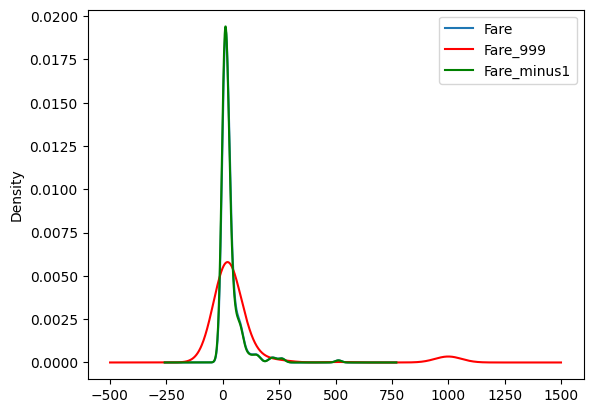

In [39]:
fig=plt.figure()
ax=fig.add_subplot(111)

X_train['Fare'].plot(kind='kde',ax=ax)
X_train['Fare_999'].plot(kind='kde',ax=ax,color='red')
X_train['Fare_minus1'].plot(kind='kde',ax=ax,color='green')

lines, labels=ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')